# Project TITAN: Enterprise Retail Intelligence Platform

## Module 3: Exploratory Data Analysis (EDA)

### Objective
Analyze the cleaned retail dataset to identify business trends, customer behavior, product performance, and sales patterns.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [12]:
df = pd.read_csv("../data/cleaned/cleaned_online_retail.csv")
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00


In [3]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
df["Revenue"].sum()

np.float64(17374804.268)

In [5]:
df["Invoice"].nunique()

36975

In [6]:
df["Customer ID"].nunique()

5881

In [7]:
df["StockCode"].nunique()

4631

In [8]:
df["Country"].nunique()


41

In [10]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Countries"
    ],
    "Value": [
        df["Revenue"].sum(),
        df["Invoice"].nunique(),
        df["Customer ID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique()
    ]
})

kpi

,Metric,Value
0,Total Revenue,1.737480e+07
1,Total Orders,3.697500e+04
2,Total Customers,5.881000e+03
3,Total Products,4.631000e+03
4,Countries,4.100000e+01


In [11]:
kpi["Value"] = kpi["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}")

kpi

,Metric,Value
0,Total Revenue,"17,374,804.27"
1,Total Orders,"36,975.00"
2,Total Customers,"5,881.00"
3,Total Products,"4,631.00"
4,Countries,41.00


In [14]:
# which country genrate highest revenue ?

country_sales = (df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))

country_sales.head(10)

Country
United Kingdom   14,389,234.92
EIRE                616,570.54
Netherlands         554,038.09
Germany             425,019.71
France              348,768.96
Australia           169,283.46
Spain               108,332.49
Switzerland         100,061.94
Sweden               91,515.82
Denmark              68,580.69
Name: Revenue, dtype: float64

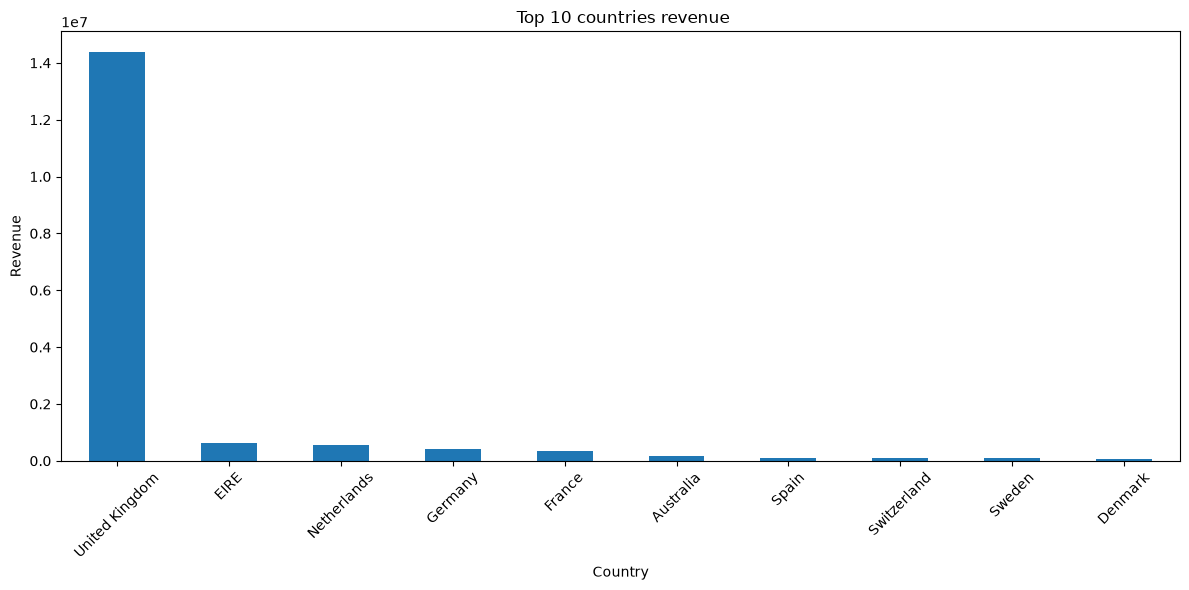

In [20]:
plt.figure(figsize=(12,6))
country_sales.head(10).plot(kind="bar")

plt.title(" Top 10 countries revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig( "../Visuals/top_10_countries_revenue.png",
    dpi=300, bbox_inches="tight")
plt.show()

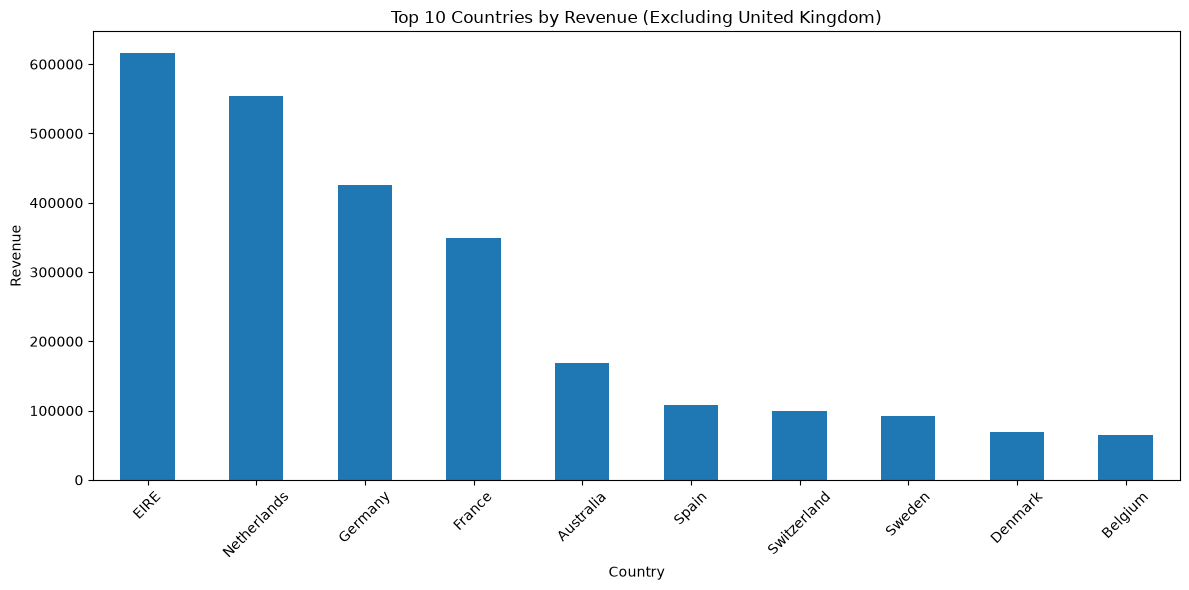

In [21]:
# top 10 countries without uk 

country_sales_without_uk = country_sales.drop("United Kingdom")

plt.figure(figsize=(12,6))

country_sales_without_uk.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue (Excluding United Kingdom)")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig( "../Visuals/top_10_countries_without_UK_revenue.png", dpi=300,
    bbox_inches="tight")

plt.show()


In [22]:
#  which products genrate highest revenue?

top_products = (df.groupby("Description")["Revenue"].sum().sort_values(ascending=False))

top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER             277,656.25
WHITE HANGING HEART T-LIGHT HOLDER   247,048.01
PAPER CRAFT , LITTLE BIRDIE          168,469.60
Manual                               151,777.67
JUMBO BAG RED RETROSPOT              134,307.44
POSTAGE                              124,648.04
ASSORTED COLOUR BIRD ORNAMENT        124,351.86
PARTY BUNTING                        103,283.38
MEDIUM CERAMIC TOP STORAGE JAR        81,416.73
PAPER CHAIN KIT 50'S CHRISTMAS        76,598.18
Name: Revenue, dtype: float64

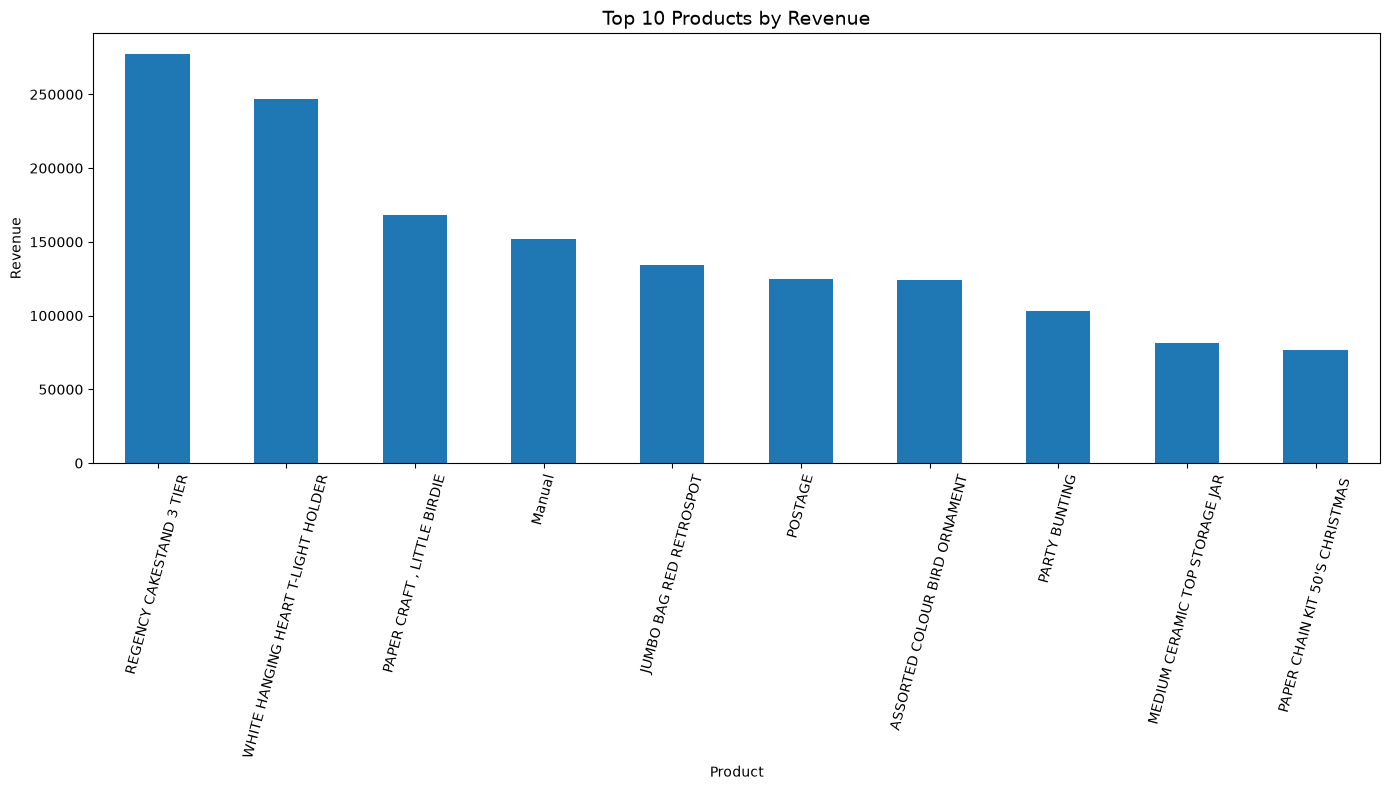

In [30]:
plt.figure(figsize=(14,8))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue",fontsize=14)
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig( "../Visuals/top_10_products_revenue.png", dpi=300,bbox_inches="tight")

plt.show()

## Business Question 3
# Who are the Top 10 Customers by Revenue?
# This analysis identifies the customers who generated the highest revenue.


In [11]:
top_customers = (df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False))

top_customers.head(10)

Customer ID
18,102.00   580,987.04
14,646.00   528,602.52
14,156.00   313,437.62
14,911.00   291,420.81
17,450.00   244,784.25
13,694.00   195,640.69
17,511.00   172,132.87
16,446.00   168,472.50
16,684.00   147,142.77
12,415.00   144,458.37
Name: Revenue, dtype: float64

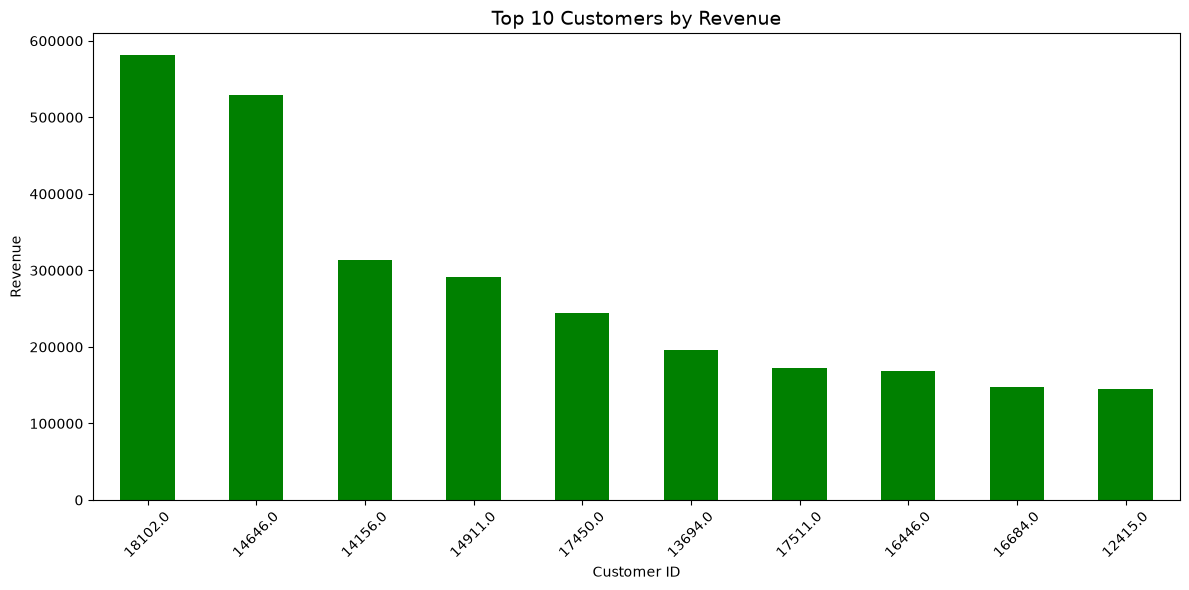

In [13]:
plt.figure(figsize=(12,6))

top_customers.head(10).plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Customers by Revenue", fontsize=14)
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Visuals/top_10_customers_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 4

### How did revenue change over time?

This analysis helps identify monthly sales trends, seasonal patterns, and business growth over time.

In [36]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = pd.to_datetime(df["InvoiceDate"]).dt.to_period("M")

In [38]:
monthly_sales = (df.groupby("Month")["Revenue"].sum()
)
labels = monthly_sales.index.strftime("%b %Y")

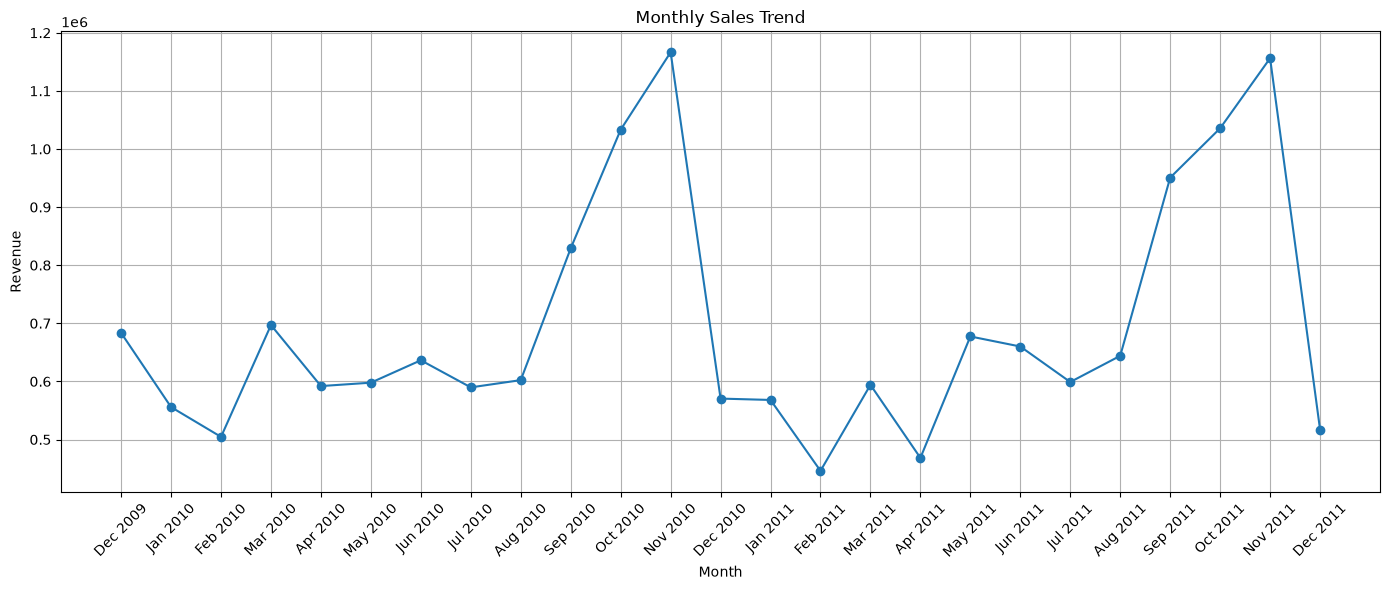

In [39]:
plt.figure(figsize=(14,6))

plt.plot(labels, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Visuals/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 5

### How did the number of orders change over time?

This analysis helps understand customer purchasing patterns and monthly order trends.

In [42]:
monthly_orders = df.groupby("Month")["Invoice"].nunique().sort_index()

monthly_orders
labels = monthly_orders.index.strftime("%b %Y")

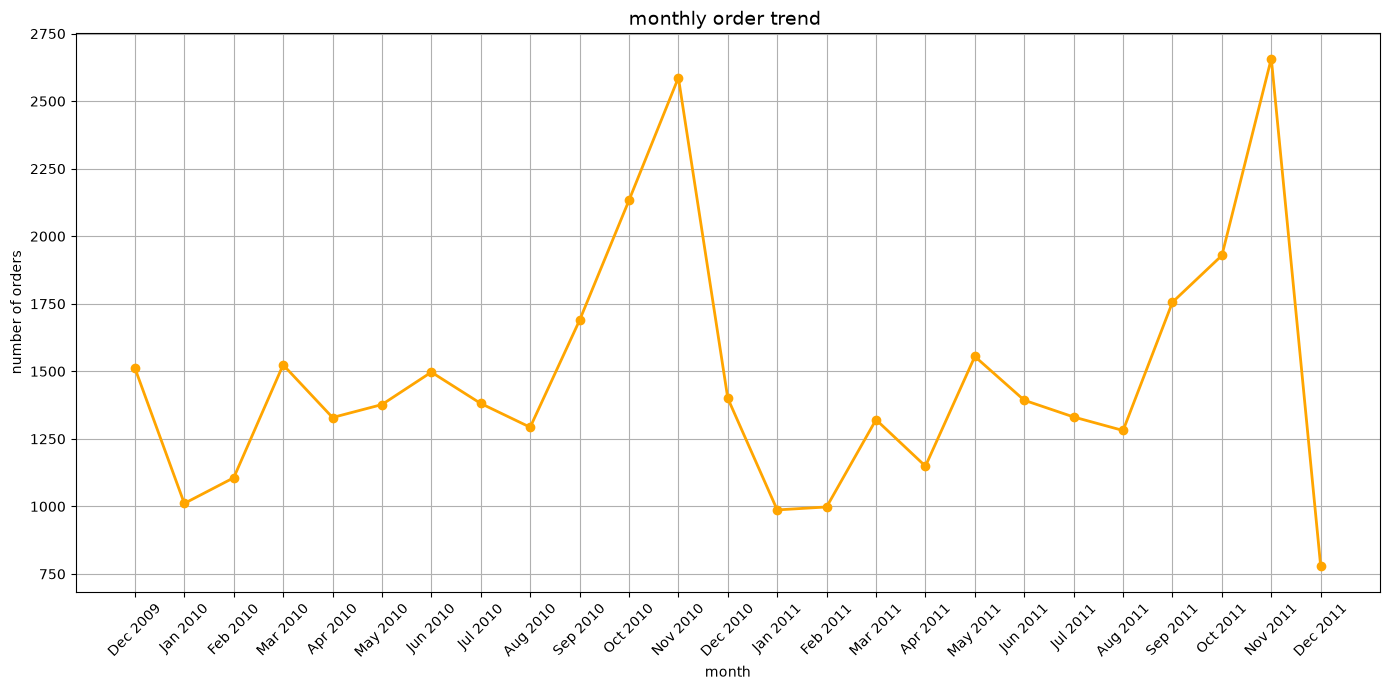

In [43]:
plt.figure(figsize=(14,7))
plt.plot(labels,monthly_orders.values,marker="o",linewidth=2,color="orange")
plt.title("monthly order trend ",fontsize=14)
plt.xlabel("month")
plt.ylabel("number of orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../Visuals/monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Business Question 6

### Which products sold the highest quantity?

This analysis identifies the most frequently purchased products based on total quantity sold.

In [44]:
top_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_quantity



Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
                                       ...  
CERAMIC CAKE TEAPOT WITH CHERRY            1
CANDY STRIPE ROSE QUILT                    1
SWALLOW SMALL TUBE MATCHES                 1
OWLS CHARLOTTE BAG                         1
 I LOVE LONDON MINI RUCKSACK               1
Name: Quantity, Length: 5283, dtype: int64

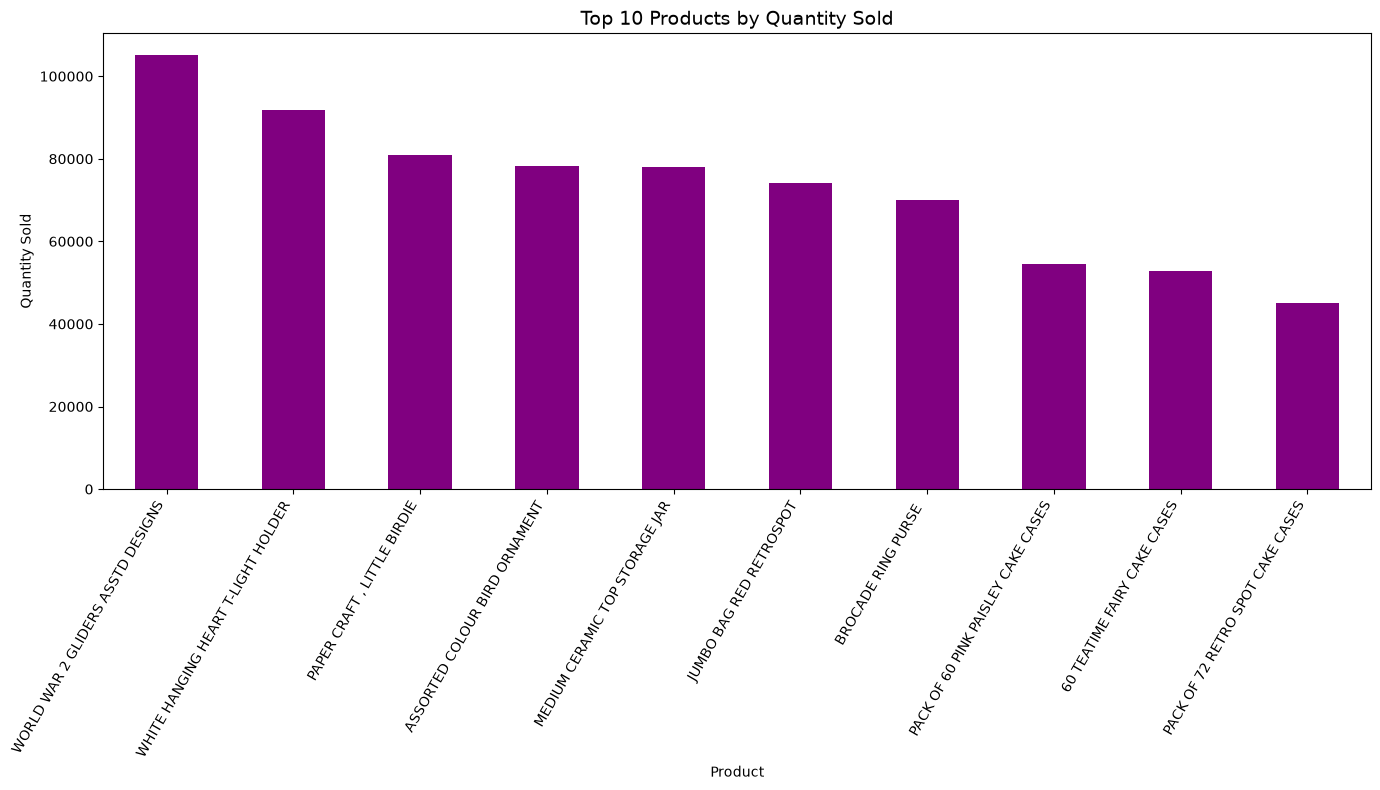

In [46]:
plt.figure(figsize=(14,8))

top_quantity.head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Products by Quantity Sold", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig(
    "../Visuals/top_10_products_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 7

### What is the distribution of transaction revenue?

This analysis helps identify the distribution of revenue and detect whether most transactions are low-value or high-value.

In [49]:
revenue_filtered = df[df["Revenue"] < df["Revenue"].quantile(0.99)]

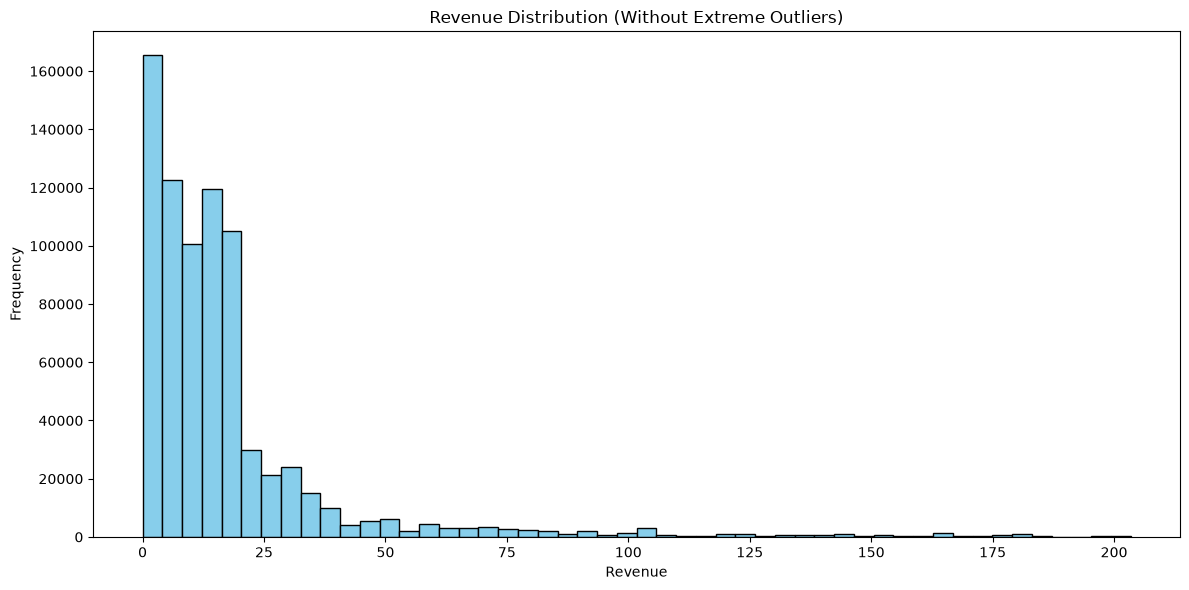

In [50]:
plt.figure(figsize=(12,6))

plt.hist(
    revenue_filtered["Revenue"],
    bins=50,
    color="skyblue",
    edgecolor="black"
)

plt.title("Revenue Distribution (Without Extreme Outliers)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../Visuals/revenue_distribution_without_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 8

### Customer Purchase Frequency

This analysis identifies how frequently customers place orders. It helps understand customer loyalty and repeat purchasing behavior.

In [51]:
customer_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

customer_frequency.head(10)

Customer ID
14,911.00    398
12,748.00    337
17,841.00    211
15,311.00    208
13,089.00    203
14,606.00    192
14,156.00    156
17,850.00    155
14,646.00    152
18,102.00    145
Name: Invoice, dtype: int64

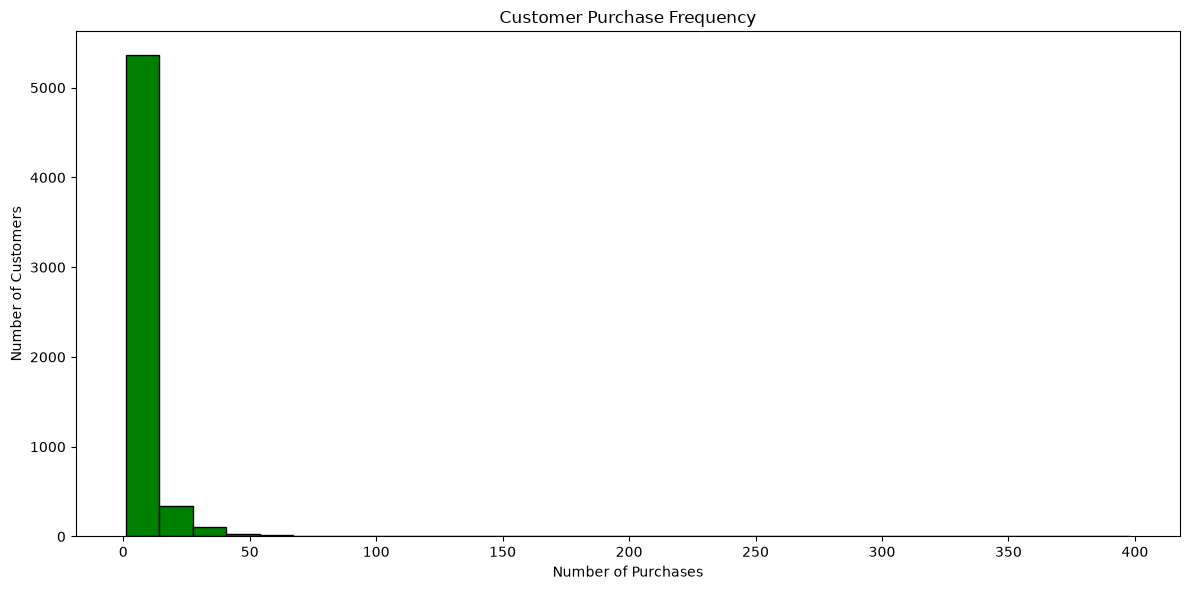

In [52]:
plt.figure(figsize=(12,6))

plt.hist(
    customer_frequency,
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../Visuals/customer_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
frequency_filtered = customer_frequency[
    customer_frequency < customer_frequency.quantile(0.99)
]

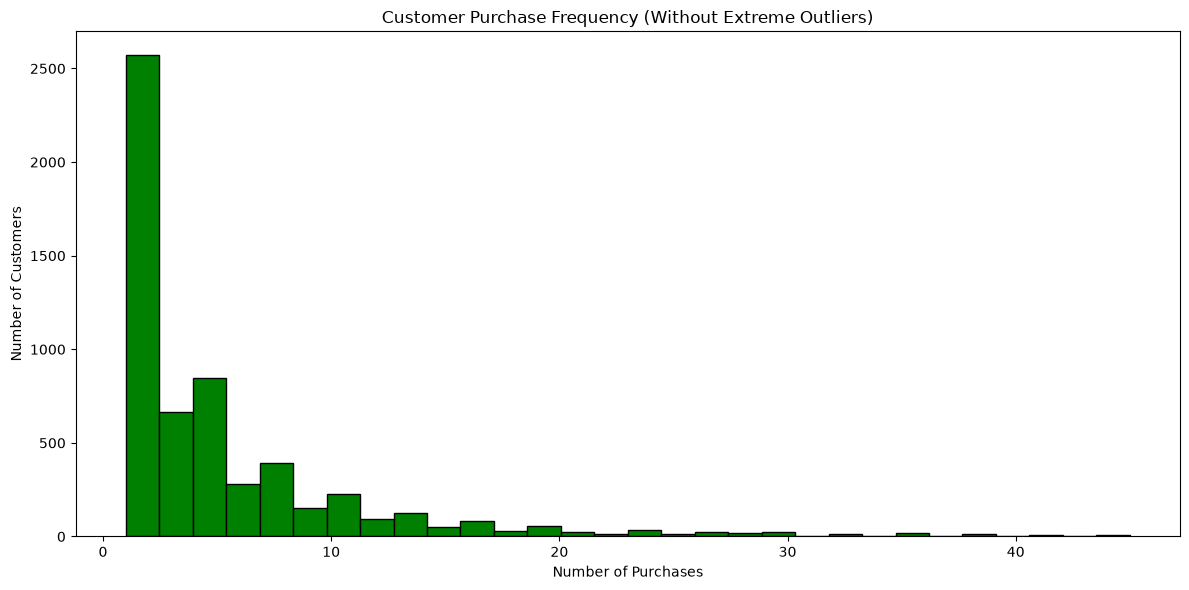

In [54]:
plt.figure(figsize=(12,6))

plt.hist(
    frequency_filtered,
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Customer Purchase Frequency (Without Extreme Outliers)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../Visuals/customer_purchase_frequency_without_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 9

### Correlation Analysis

This analysis identifies the relationship between numerical variables using a correlation heatmap.

In [55]:
correlation = df[["Quantity", "Price", "Revenue"]].corr()

correlation

,Quantity,Price,Revenue
Quantity,1.00,-0.00,0.82
Price,-0.00,1.00,0.14
Revenue,0.82,0.14,1.00


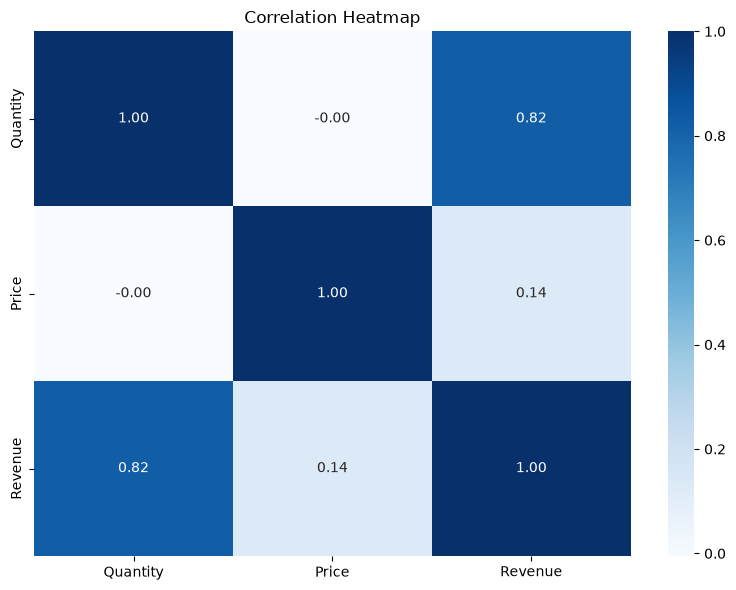

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../Visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()